## LLM Results Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in results files
df_amarillo = pd.read_csv('district_analyses_results/Amarillo/Amarillo_summary.csv')
df_austin = pd.read_csv('district_analyses_results/Austin/Austin_summary.csv')
df_chico = pd.read_csv('district_analyses_results/Chico/Chico_summary.csv')
df_clear_creek = pd.read_csv('district_analyses_results/Clear-Creek/Clear-Creek_summary.csv')
df_fabens = pd.read_csv('district_analyses_results/Fabens/Fabens_summary.csv')
df_huffman = pd.read_csv('district_analyses_results/Huffman/Huffman_summary.csv')
df_kerrville = pd.read_csv('district_analyses_results/Kerrville/Kerrville_summary.csv')
df_la_feria = pd.read_csv('district_analyses_results/La-Feria/La-Feria_summary.csv')
df_libery_eylau = pd.read_csv('district_analyses_results/Libery-Eylau/Libery-Eylau_summary.csv')
df_longview = pd.read_csv('district_analyses_results/Longview/Longview_summary.csv')
df_san_isidro = pd.read_csv('district_analyses_results/San-Isidro/San-Isidro_summary.csv')
df_terrell = pd.read_csv('district_analyses_results/Terrell/Terrell_summary.csv')

In [3]:
# Combine all dataframes into one
df_list = [df_amarillo, df_austin, df_chico, df_clear_creek, df_fabens, df_huffman, df_kerrville, df_la_feria, df_libery_eylau, df_longview, df_san_isidro, df_terrell]
df = pd.concat(df_list, ignore_index = True)

In [4]:
df.head(15)

,district,state,total number of drug or alcohol terms mentioned,number of times suspension or synonyms are mentioned,number of times expulsion or synonyms is mentioned,number of time transfer or referral to disciplinary alternative school is mentioned,number of times transfer or referral to juvenile justice program is mentioned,number of times arrest or synonyms are mentioned,number of times drug sniffing dogs or other drug screening procedures are mentioned,number of times police or school resource officers are mentioned,number of times any other terms are mentioned that relate to disciplinary approaches to student drug and alcohol use,number of times transfer or referral to treatment programs are mentioned,number of times transfer or referral to recovery schools are mentioned,number of times school based health centers or synonyms are mentioned,number of times transfer or referral to mental health clinics or other off campus health facilities are mentioned,number of times trauma-informed care or synonyms are mentioned,number of times restorative justice approaches or synonyms are mentioned,number of times drug and alcohol use prevention programs are mentioned,"number of times health-services staff such as school nurses, social workers, psychologists, or substance use counselors are mentioned",number of times any other terms are mentioned that relate to a health-oriented approach to student drug and alcohol use
0,Amarillo,Texas,195,64,95,18,46,1,0,4,119,2,12,0,0,8,2,24,58,48
1,Austin,Texas,245,72,102,19,49,1,0,4,162,2,12,0,0,9,8,29,68,55
2,Chico,Texas,201,65,96,19,46,1,0,4,120,2,12,0,0,9,2,27,60,53
3,Clear-Creek,Texas,211,71,96,19,46,1,0,4,120,2,12,0,0,9,2,27,61,52
4,Fabens,Texas,207,65,96,24,46,1,0,4,123,2,12,0,0,9,2,27,61,52
5,Huffman,Texas,213,59,91,18,46,1,0,3,106,2,11,0,0,9,2,25,60,52
6,Kerrville,Texas,293,82,93,18,46,1,0,4,129,2,12,0,0,8,2,24,59,47
7,La-Feria,Texas,198,65,96,19,46,1,0,4,120,1,12,0,0,9,2,27,36,51
8,Libery-Eylau,Texas,208,65,96,23,46,1,0,4,119,2,12,0,0,9,2,27,61,52
9,Longview,Texas,211,65,96,23,46,1,0,4,123,2,12,0,0,9,2,27,61,52


In [5]:
# Create two new summary columns for disciplinary & health/treatment terms mentioned
df['total number of disciplinary terms mentioned'] = (
    df['number of times suspension or synonyms are mentioned'] +
    df['number of times expulsion or synonyms is mentioned'] +
    df['number of time transfer or referral to disciplinary alternative school is mentioned'] +
    df['number of times transfer or referral to juvenile justice program is mentioned'] + 
    df['number of times arrest or synonyms are mentioned'] + 
    df['number of times drug sniffing dogs or other drug screening procedures are mentioned'] +
    df['number of times police or school resource officers are mentioned'] +
    df['number of times any other terms are mentioned that relate to disciplinary approaches to student drug and alcohol use']
)

df['total number of health or treatment terms mentioned'] = (
    df['number of times transfer or referral to treatment programs are mentioned'] +
    df['number of times transfer or referral to recovery schools are mentioned'] +
    df['number of times school based health centers or synonyms are mentioned'] + 
    df['number of times transfer or referral to mental health clinics or other off campus health facilities are mentioned'] + 
    df['number of times trauma-informed care or synonyms are mentioned'] + 
    df['number of times restorative justice approaches or synonyms are mentioned'] + 
    df['number of times drug and alcohol use prevention programs are mentioned'] + 
    df['number of times health-services staff such as school nurses, social workers, psychologists, or substance use counselors are mentioned'] +
    df['number of times any other terms are mentioned that relate to a health-oriented approach to student drug and alcohol use']
)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 22 columns):
 #   Column                                                                                                                                 Non-Null Count  Dtype
---  ------                                                                                                                                 --------------  -----
 0   district                                                                                                                               12 non-null     str  
 1   state                                                                                                                                  12 non-null     str  
 2   total number of drug or alcohol terms mentioned                                                                                        12 non-null     int64
 3   number of times suspension or synonyms are mentioned                                         

In [7]:
col1 = df.pop("total number of disciplinary terms mentioned")
col2 = df.pop("total number of health or treatment terms mentioned")

df.insert(3, col1.name, col1)
df.insert(4, col2.name, col2)

In [11]:
# Save the combined dataframe to a new CSV file
df.to_csv('district_analyses_results/overall-summary.csv', index=False)

In [9]:
df['d_ratio'] = df['total number of disciplinary terms mentioned'] / (df['total number of disciplinary terms mentioned'] + df['total number of health or treatment terms mentioned'])
df['h_ratio'] = df['total number of health or treatment terms mentioned'] / (df['total number of disciplinary terms mentioned'] + df['total number of health or treatment terms mentioned'])

In [10]:
df.head(15)

,district,state,total number of drug or alcohol terms mentioned,total number of disciplinary terms mentioned,total number of health or treatment terms mentioned,number of times suspension or synonyms are mentioned,number of times expulsion or synonyms is mentioned,number of time transfer or referral to disciplinary alternative school is mentioned,number of times transfer or referral to juvenile justice program is mentioned,number of times arrest or synonyms are mentioned,...,number of times transfer or referral to recovery schools are mentioned,number of times school based health centers or synonyms are mentioned,number of times transfer or referral to mental health clinics or other off campus health facilities are mentioned,number of times trauma-informed care or synonyms are mentioned,number of times restorative justice approaches or synonyms are mentioned,number of times drug and alcohol use prevention programs are mentioned,"number of times health-services staff such as school nurses, social workers, psychologists, or substance use counselors are mentioned",number of times any other terms are mentioned that relate to a health-oriented approach to student drug and alcohol use,d_ratio,h_ratio
0,Amarillo,Texas,195,347,154,64,95,18,46,1,...,12,0,0,8,2,24,58,48,0.692615,0.307385
1,Austin,Texas,245,409,183,72,102,19,49,1,...,12,0,0,9,8,29,68,55,0.690878,0.309122
2,Chico,Texas,201,351,165,65,96,19,46,1,...,12,0,0,9,2,27,60,53,0.680233,0.319767
3,Clear-Creek,Texas,211,357,165,71,96,19,46,1,...,12,0,0,9,2,27,61,52,0.683908,0.316092
4,Fabens,Texas,207,359,165,65,96,24,46,1,...,12,0,0,9,2,27,61,52,0.685115,0.314885
5,Huffman,Texas,213,324,161,59,91,18,46,1,...,11,0,0,9,2,25,60,52,0.668041,0.331959
6,Kerrville,Texas,293,373,154,82,93,18,46,1,...,12,0,0,8,2,24,59,47,0.707780,0.292220
7,La-Feria,Texas,198,351,138,65,96,19,46,1,...,12,0,0,9,2,27,36,51,0.717791,0.282209
8,Libery-Eylau,Texas,208,354,165,65,96,23,46,1,...,12,0,0,9,2,27,61,52,0.682081,0.317919
9,Longview,Texas,211,358,165,65,96,23,46,1,...,12,0,0,9,2,27,61,52,0.684512,0.315488


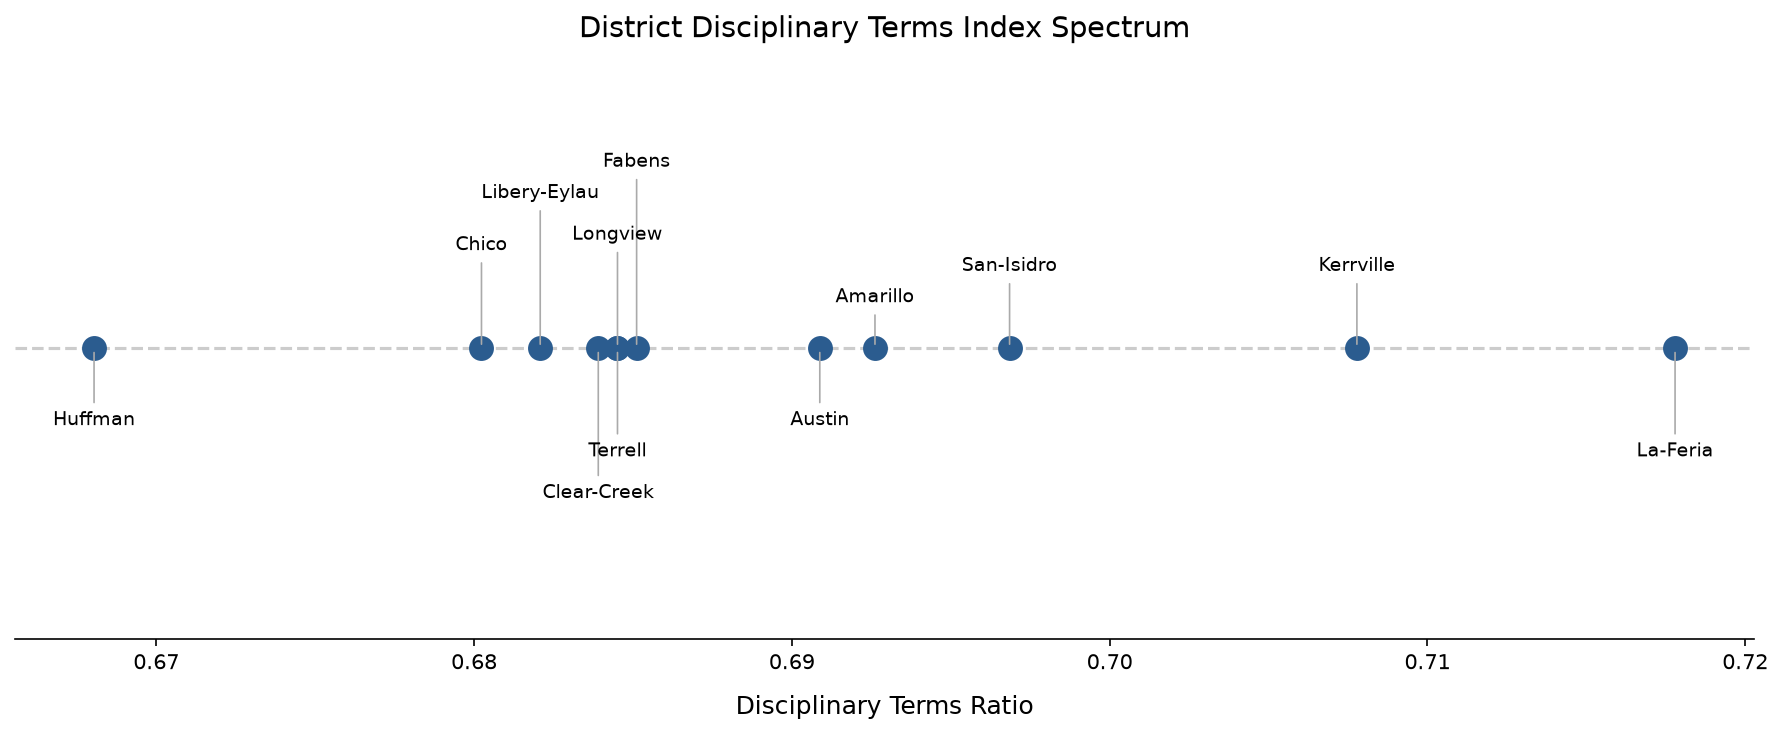

In [14]:
df_d_ratio = df.sort_values(by = 'd_ratio').reset_index(drop = True)

fig, ax = plt.subplots(figsize = (12, 5), dpi = 150)

ax.axhline(0, color = '#cccccc', linestyle = '--', linewidth = 1.5, zorder = 1)
ax.scatter(df['d_ratio'], np.zeros(len(df)), color = '#2b5c8f', s = 120, zorder = 3)

offsets = [20, -30, 45, -65, 85, -30, 35, -45, 70, 50, 35, -45]

for i, row in df.iterrows():
    offset = offsets[i % len(offsets)]
    ax.annotate(
        row['district'],
        (row['d_ratio'], 0),
        xytext=(0, offset),
        textcoords="offset points",
        ha='center',
        va='bottom' if offset > 0 else 'top',
        fontsize=9,
        arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.8)
    )

ax.set_ylim(-0.1, 0.1)
ax.get_yaxis().set_visible(False) 
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Disciplinary Terms Ratio', fontsize = 12, labelpad = 10)
ax.set_title('District Disciplinary Terms Index Spectrum', fontsize = 14, pad = 10)
plt.tight_layout()
plt.show()

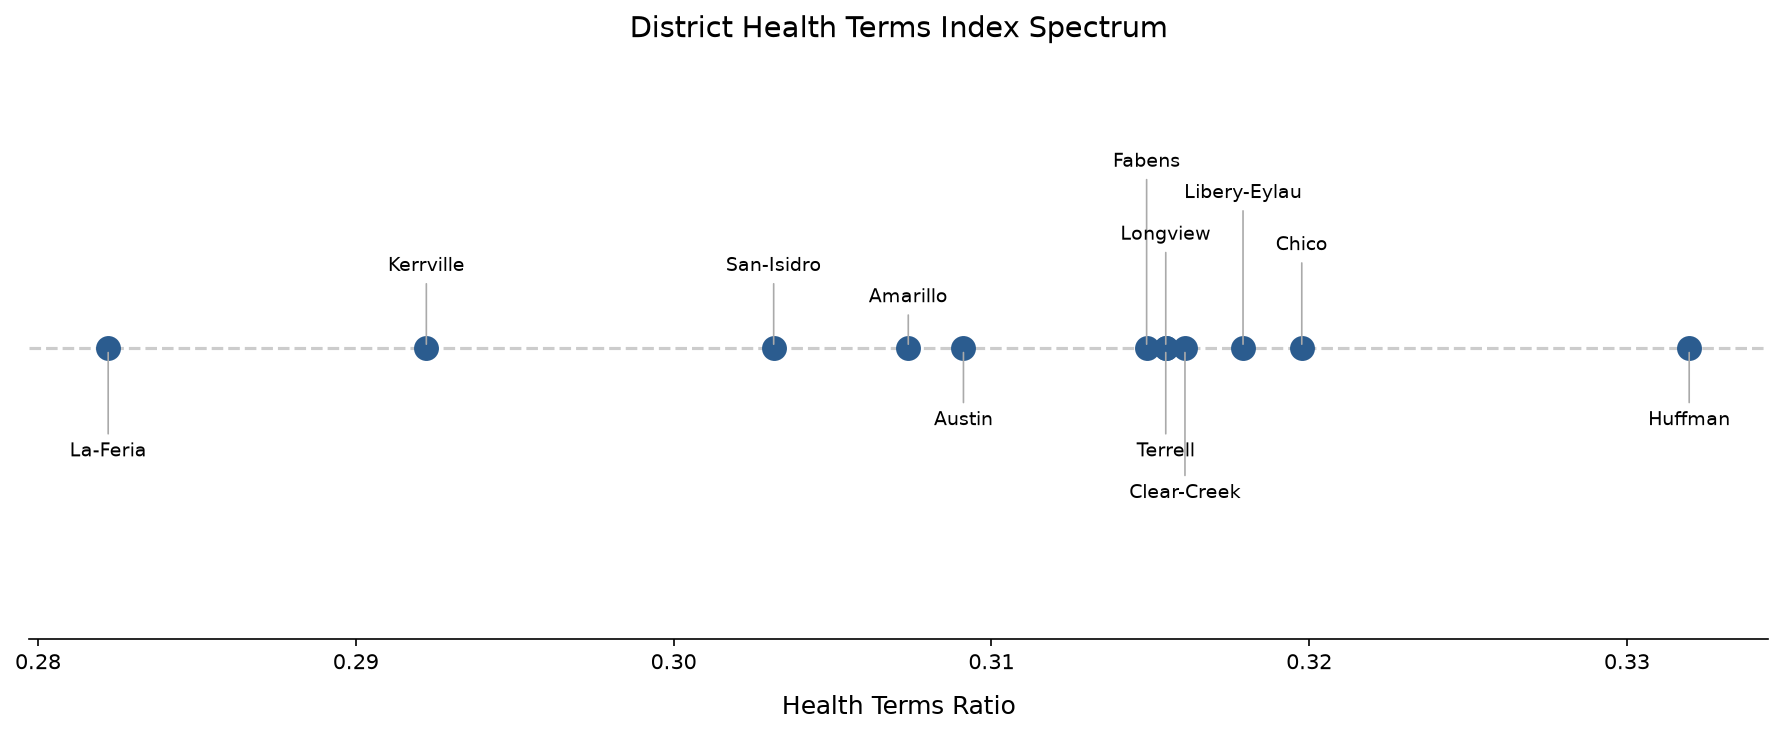

In [16]:
df_d_ratio = df.sort_values(by = 'h_ratio').reset_index(drop = True)

fig, ax = plt.subplots(figsize = (12, 5), dpi = 150)

ax.axhline(0, color = '#cccccc', linestyle = '--', linewidth = 1.5, zorder = 1)
ax.scatter(df['h_ratio'], np.zeros(len(df)), color = '#2b5c8f', s = 120, zorder = 3)

offsets = [20, -30, 45, -65, 85, -30, 35, -45, 70, 50, 35, -45]

for i, row in df.iterrows():
    offset = offsets[i % len(offsets)]
    ax.annotate(
        row['district'],
        (row['h_ratio'], 0),
        xytext=(0, offset),
        textcoords="offset points",
        ha='center',
        va='bottom' if offset > 0 else 'top',
        fontsize=9,
        arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.8)
    )

ax.set_ylim(-0.1, 0.1)
ax.get_yaxis().set_visible(False) 
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Health Terms Ratio', fontsize = 12, labelpad = 10)
ax.set_title('District Health Terms Index Spectrum', fontsize = 14, pad = 10)
plt.tight_layout()
plt.show()